In [4]:
# PARTE A1
# PARTE A.1  División train/test y tabla de diferencia de medias
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from scipy import stats

# en este paso fijo paths y cargo la base
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron_final.xlsx"
df = pd.read_excel(file_resp)

# en este paso verifico columnas obligatorias
if not {"pobre","anio"}.issubset(df.columns):
    raise KeyError("Faltan columnas obligatorias: pobre y/o anio")

# en este paso tipifico pobre y anio
df["pobre"] = pd.to_numeric(df["pobre"], errors="coerce")
df["anio"] = pd.to_numeric(df["anio"], errors="coerce")

# en este paso defino filtro para excluir todo lo ligado a ingreso
bloquear = {"ingreso", "itf", "itfipc", "itf_hogar", "ingreso_per_capita", "ingreso_necesario"}
def es_ingreso(col):
    c = str(col).lower()
    return any(tok in c for tok in bloquear)

# en este paso selecciono todas las variables elegibles excepto pobre, anio y las ligadas a ingreso
vars_X_base = [
    c for c in df.columns
    if c not in {"pobre", "anio"} and not es_ingreso(c)
]

# en este paso construyo X usando solo variables numéricas y mantengo nombres originales
def construir_X(subdf, cols):
    # en este paso filtro a numéricas
    X_num = subdf[cols].select_dtypes(include=[np.number]).apply(pd.to_numeric, errors="coerce")
    # en este paso agrego la constante para el intercepto
    X = X_num.copy()
    X.insert(0, "constante", 1.0)
    return X

# en este paso separo por año
resp_2005 = df[df["anio"] == 2005].copy()
resp_2025 = df[df["anio"] == 2025].copy()

# en este paso construyo matrices X e y por año
X2005 = construir_X(resp_2005, vars_X_base)
y2005 = resp_2005["pobre"].astype(float)

X2025 = construir_X(resp_2025, vars_X_base)
y2025 = resp_2025["pobre"].astype(float)

# en este paso divido 70/30 con semilla 444
Xtr05, Xte05, ytr05, yte05 = train_test_split(X2005, y2005, test_size=0.3, random_state=444)
Xtr25, Xte25, ytr25, yte25 = train_test_split(X2025, y2025, test_size=0.3, random_state=444)

print(f"2005 → train {Xtr05.shape[0]}  test {Xte05.shape[0]}")
print(f"2025 → train {Xtr25.shape[0]}  test {Xte25.shape[0]}")

# en este paso creo función de diferencia de medias con test t de Welch
def tabla_diff_medias(X_train, X_test, excluir=("constante",)):
    cols_eval = [c for c in X_train.columns if c not in excluir]
    filas = []
    for c in cols_eval:
        a = pd.to_numeric(X_train[c], errors="coerce").dropna()
        b = pd.to_numeric(X_test[c],  errors="coerce").dropna()
        if len(a)==0 or len(b)==0:
            continue
        tstat, pval = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        filas.append({
            "variable": c,
            "media_train": a.mean(),
            "media_test": b.mean(),
            "diferencia": a.mean() - b.mean(),
            "t_stat": tstat,
            "p_value": pval,
            "n_train": a.size,
            "n_test": b.size
        })
    out = pd.DataFrame(filas)
    return out.sort_values("p_value").reset_index(drop=True)

# en este paso calculo tablas por año
diff05 = tabla_diff_medias(Xtr05, Xte05)
diff25 = tabla_diff_medias(Xtr25, Xte25)

# en este paso exporto a Excel
out05 = PATH_BASES / "tabla_diff_medias_train_vs_test_2005.xlsx"
out25 = PATH_BASES / "tabla_diff_medias_train_vs_test_2025.xlsx"
with pd.ExcelWriter(out05, engine="openpyxl") as w:
    diff05.to_excel(w, index=False, sheet_name="diff_medias_2005")
with pd.ExcelWriter(out25, engine="openpyxl") as w:
    diff25.to_excel(w, index=False, sheet_name="diff_medias_2025")

# en este paso muestro top filas para control rápido
print("\nTop variables con mayor evidencia de diferencia 2005")
print(diff05.head(10).to_string(index=False))
print("\nTop variables con mayor evidencia de diferencia 2025")
print(diff25.head(10).to_string(index=False))



2005 → train 5588  test 2396
2025 → train 1836  test 787

Top variables con mayor evidencia de diferencia 2005
                 variable  media_train  media_test  diferencia    t_stat  p_value  n_train  n_test
                    edad2  1658.640122 1703.818030  -45.177908 -1.026395 0.304761     5588    2396
            estado_empleo     2.156110    2.181475   -0.025365 -0.921491 0.356843     5573    2386
               parentesco     2.046090    2.084795   -0.038705 -0.898095 0.369183     5576    2394
                     edad    34.546349   34.996661   -0.450312 -0.846061 0.397564     5588    2396
          nivel_ocupacion     4.232999    4.307596   -0.074597 -0.807828 0.419239     5588    2396
               n_personas     4.322119    4.292154    0.029965  0.709538 0.478027     5588    2396
     tipo_cobertura_salud     1.651038    1.642321    0.008717  0.669368 0.503296     5588    2396
    categoria_inactividad     1.618826    1.646912   -0.028085 -0.596231 0.551051     5588    239

In [5]:
# PARTE A.2 - Separar bases respondieron y norespondieron por año
import pandas as pd
from pathlib import Path

# en este paso cargo las bases
PATH_BASES = Path.cwd()
file_resp = PATH_BASES / "respondieron_final.xlsx"
file_noresp = PATH_BASES / "norespondieron.xlsx"

respondieron = pd.read_excel(file_resp)
norespondieron = pd.read_excel(file_noresp)

# en este paso tipifico el año
respondieron["anio"] = pd.to_numeric(respondieron["anio"], errors="coerce")
norespondieron["anio"] = pd.to_numeric(norespondieron["anio"], errors="coerce")

# en este paso creo los subconjuntos por año
respondieron_2005 = respondieron[respondieron["anio"] == 2005].copy()
respondieron_2025 = respondieron[respondieron["anio"] == 2025].copy()

norespondieron_2005 = norespondieron[norespondieron["anio"] == 2005].copy()
norespondieron_2025 = norespondieron[norespondieron["anio"] == 2025].copy()

# en este paso muestro el tamaño de cada subconjunto
print("respondieron_2005:", respondieron_2005.shape)
print("respondieron_2025:", respondieron_2025.shape)
print("norespondieron_2005:", norespondieron_2005.shape)
print("norespondieron_2025:", norespondieron_2025.shape)

# en este paso guardo las bases separadas
respondieron_2005.to_excel(PATH_BASES / "respondieron_2005.xlsx", index=False)
respondieron_2025.to_excel(PATH_BASES / "respondieron_2025.xlsx", index=False)
norespondieron_2005.to_excel(PATH_BASES / "norespondieron_2005.xlsx", index=False)
norespondieron_2025.to_excel(PATH_BASES / "norespondieron_2025.xlsx", index=False)

print("Listo, se generaron las 4 bases por año.")



respondieron_2005: (7984, 31)
respondieron_2025: (2623, 31)
norespondieron_2005: (12, 21)
norespondieron_2025: (534, 21)
Listo, se generaron las 4 bases por año.


---

# Modelo de Regresion Logistica

* 3) Estimacion y efectos Marginales


In [6]:
#Librerias a utilizar Punto B y D
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Estimación del modelo
logit_sm = sm.Logit(ytr25, Xtr25) #Logit con las variables de entrenamiento de 2025
res_logit = logit_sm.fit(disp=0)

# Tabla de resultados con coef, std err y odds-ratio
tabla_logit = pd.DataFrame({
    "Variable": Xtr25.columns,
    "Coeficiente": res_logit.params,
    "Error Std.": res_logit.bse,
    "p-valor": res_logit.pvalues,
})
tabla_logit["Odds Ratio"] = np.exp(tabla_logit["Coeficiente"])

display(tabla_logit.round(4))

# Exportar a Excel
tabla_logit.to_excel("resultados_logit_2025.xlsx", index=False)

#Predicciones
y_prob_logit = res_logit.predict(Xte25)

#desempeño
y_pred_logit = (y_prob_logit >= 0.5).astype(int)
print(classification_report(yte25, y_pred_logit))


C:\Users\War\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Variable,Coeficiente,Error Std.,p-valor,Odds Ratio
constante,constante,-5.5307,1.4974,0.0002,0.0040
Distincion_vivienda_hogar,Distincion_vivienda_hogar,-0.1204,0.4528,0.7903,0.8866
genero,genero,0.4514,0.2391,0.0591,1.5705
edad,edad,0.0746,0.0328,0.0228,1.0774
tipo_empleo,tipo_empleo,0.0995,0.0638,0.1185,1.1047
parentesco,parentesco,0.0950,0.0313,0.0024,1.0996
nivel_educ,nivel_educ,-0.0010,0.0537,0.9851,0.9990
estado_empleo,estado_empleo,0.0047,0.2247,0.9834,1.0047
categoria_inactividad,categoria_inactividad,0.3221,0.0838,0.0001,1.3800
tipo_cobertura_salud,tipo_cobertura_salud,-0.6088,0.2573,0.0180,0.5440


              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92       659
         1.0       0.64      0.23      0.34       128

    accuracy                           0.85       787
   macro avg       0.76      0.60      0.63       787
weighted avg       0.83      0.85      0.82       787



* 4) Visualización

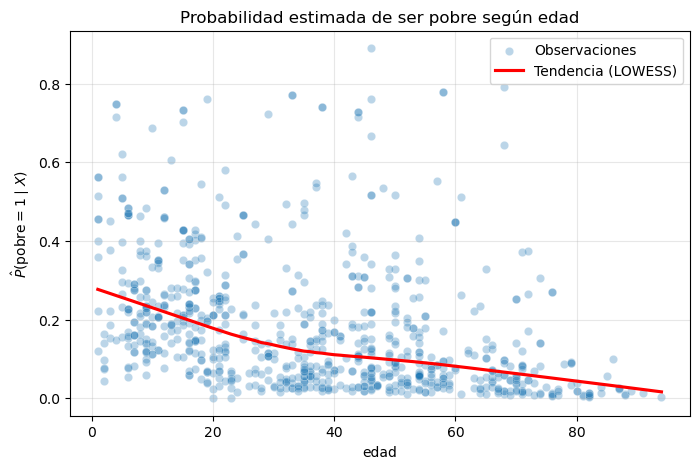

In [7]:
import seaborn as sns
# Selecciono una variable numérica relevante
var_num = "edad" if "edad" in Xte25.columns else "cantidad_miembros"

#  DataFrame con probabilidad predicha y la variable elegida
df_plot = pd.DataFrame({
    var_num: Xte25[var_num],
    "prob_pobre": y_prob_logit
})

# Gráfico el scatter mas la linea de tendencia
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_plot, x=var_num, y="prob_pobre", alpha=0.3, label="Observaciones")
sns.regplot(data=df_plot, x=var_num, y="prob_pobre",
            lowess=True, scatter=False, color="red", label="Tendencia (LOWESS)")
plt.title(f"Probabilidad estimada de ser pobre según {var_num}")
plt.xlabel(var_num)
plt.ylabel(r"$\hat{P}(\text{pobre}=1 \mid X)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


---

# Método de Vecinos Cercanos (KNN)


* 5) Estimación

In [8]:
#PARTE C.5

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Aseguro entrada numérica (si hay categóricas, paso a dummies)
Xtr25_knn = pd.get_dummies(Xtr25, drop_first=True)
Xte25_knn = pd.get_dummies(Xte25, drop_first=True)
# Alineo columnas entre train y test
Xte25_knn = Xte25_knn.reindex(columns=Xtr25_knn.columns, fill_value=0)

resultados_knn = {}

for k in [1, 5, 10]:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),  # no centra, útil con dummies dispersas
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(Xtr25_knn, ytr25)
    ypred = pipe.predict(Xte25_knn)
    resultados_knn[k] = {"modelo": pipe, "y_pred": ypred}

    print(f"\n=== KNN (K={k}) — desempeño en test 2025 ===")
    print(classification_report(yte25, ypred, digits=3))



=== KNN (K=1) — desempeño en test 2025 ===
              precision    recall  f1-score   support

         0.0      0.983     0.979     0.981       659
         1.0      0.893     0.914     0.903       128

    accuracy                          0.968       787
   macro avg      0.938     0.946     0.942       787
weighted avg      0.969     0.968     0.968       787


=== KNN (K=5) — desempeño en test 2025 ===
              precision    recall  f1-score   support

         0.0      0.911     0.958     0.933       659
         1.0      0.702     0.516     0.595       128

    accuracy                          0.886       787
   macro avg      0.806     0.737     0.764       787
weighted avg      0.877     0.886     0.878       787


=== KNN (K=10) — desempeño en test 2025 ===
              precision    recall  f1-score   support

         0.0      0.880     0.956     0.916       659
         1.0      0.592     0.328     0.422       128

    accuracy                          0.854      

* 6) Visualización

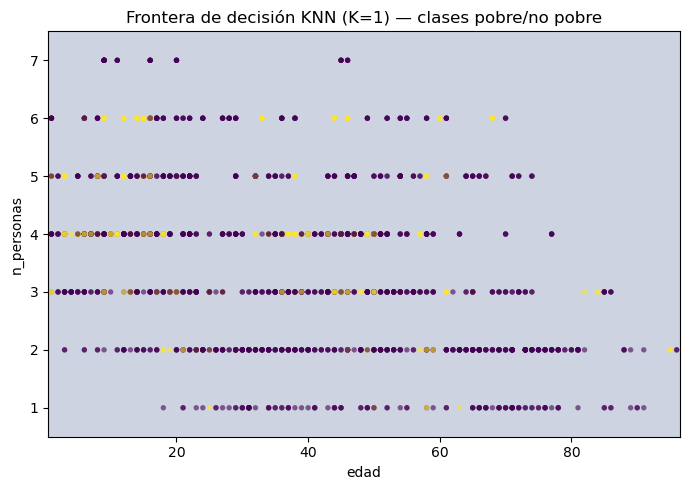

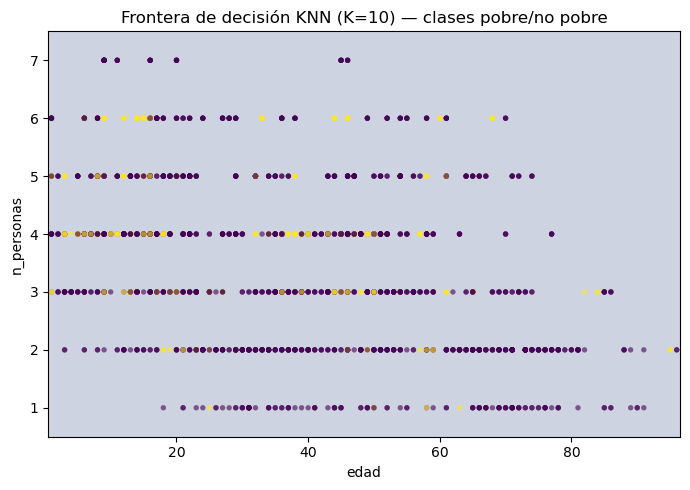

In [9]:
#PARTE C.6

import matplotlib.pyplot as plt


# Reutilizo matrices del Ítem 5; si no existen (celda corrida en frío), las creo al vuelo
if "Xtr25_knn" not in globals():
    Xtr25_knn = pd.get_dummies(Xtr25, drop_first=True)
    Xte25_knn = pd.get_dummies(Xte25, drop_first=True)
    Xte25_knn = Xte25_knn.reindex(columns=Xtr25_knn.columns, fill_value=0)

# Si no tengo modelos K=1 y K=10 entrenados, los entreno rápido
if "resultados_knn" not in globals() or (1 not in resultados_knn or 10 not in resultados_knn):
    resultados_knn = {}
    for k in [1, 10]:
        pipe = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])
        pipe.fit(Xtr25_knn, ytr25)
        resultados_knn[k] = {"modelo": pipe}

# Selección de dos features “típicas” de la materia si existen; si no, primeras dos columnas
preferidas = [c for c in ["edad", "cantidad_miembros", "n_personas", "horastrab"] if c in Xtr25_knn.columns]
f1, f2 = (preferidas + list(Xtr25_knn.columns))[:2]

def plot_frontera(modelo, k):
    # Malla en el espacio (f1, f2)
    x_min, x_max = Xtr25_knn[f1].min() - 0.5, Xtr25_knn[f1].max() + 0.5
    y_min, y_max = Xtr25_knn[f2].min() - 0.5, Xtr25_knn[f2].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # Armamos un DataFrame con TODAS las columnas de Xtr25_knn, seteo 0 salvo f1 y f2
    base = pd.DataFrame(0, index=np.arange(xx.size), columns=Xtr25_knn.columns)
    base[f1] = xx.ravel()
    base[f2] = yy.ravel()

    Z = modelo.predict(base).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25, levels=2)
    plt.scatter(Xtr25_knn[f1], Xtr25_knn[f2], c=ytr25, s=15, alpha=0.6, edgecolor='none')
    plt.title(f"Frontera de decisión KNN (K={k}) — clases pobre/no pobre")
    plt.xlabel(f1); plt.ylabel(f2)
    plt.tight_layout()
    plt.show()

# Mostrar fronteras para K=1 y K=10
plot_frontera(resultados_knn[1]["modelo"], 1)
plot_frontera(resultados_knn[10]["modelo"], 10)


* 7) K optimo por Cross-validation


=== CV 5-fold — Accuracy por K ===


,K,accuracy_mean,accuracy_std
0,1,0.9276,0.0092
1,2,0.9118,0.0078
2,3,0.8889,0.0122
3,4,0.8595,0.0070
4,5,0.8464,0.0087
5,6,0.8410,0.0079
6,7,0.8426,0.0078
7,8,0.8284,0.0053
8,9,0.8268,0.0082
9,10,0.8268,0.0118



K óptimo (CV 5-fold, métrica accuracy): 1

=== KNN con K–CV — desempeño en test 2025 ===
              precision    recall  f1-score   support

         0.0      0.983     0.979     0.981       659
         1.0      0.893     0.914     0.903       128

    accuracy                          0.968       787
   macro avg      0.938     0.946     0.942       787
weighted avg      0.969     0.968     0.968       787



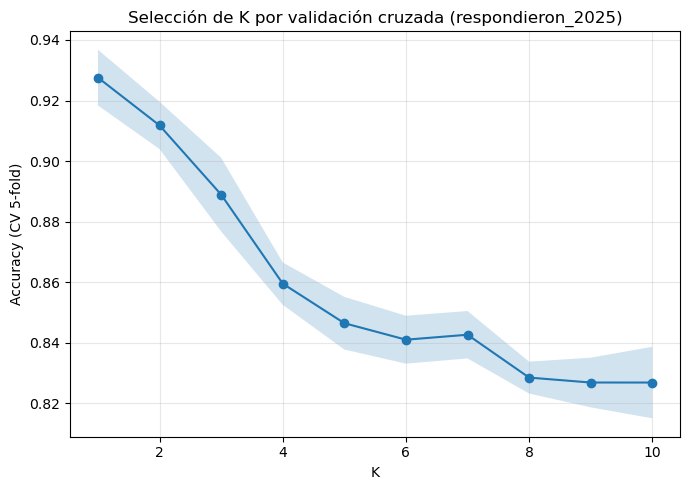

In [10]:
#PARTE C.7

from sklearn.model_selection import cross_val_score


# Reuso matrices del Ítem 5; si no existen, las genero al vuelo
if "Xtr25_knn" not in globals():
    Xtr25_knn = pd.get_dummies(Xtr25, drop_first=True)
    Xte25_knn = pd.get_dummies(Xte25, drop_first=True)
    Xte25_knn = Xte25_knn.reindex(columns=Xtr25_knn.columns, fill_value=0)

ks = list(range(1, 10+1))
acc_mean, acc_std = [], []

for k in ks:
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, Xtr25_knn, ytr25, cv=5, scoring="accuracy", n_jobs=-1)
    acc_mean.append(scores.mean())
    acc_std.append(scores.std())

# Tabla de resultados CV
cv_df = pd.DataFrame({"K": ks, "accuracy_mean": acc_mean, "accuracy_std": acc_std})
print("\n=== CV 5-fold — Accuracy por K ===")
display(cv_df.round(4))

# Selección de K óptimo (máximo accuracy promedio)
k_opt = cv_df.loc[cv_df["accuracy_mean"].idxmax(), "K"]
print(f"\nK óptimo (CV 5-fold, métrica accuracy): {int(k_opt)}")

# Entreno el modelo final KNN con K–CV en todo Xtr25
pipe_kcv = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("knn", KNeighborsClassifier(n_neighbors=int(k_opt)))
])
pipe_kcv.fit(Xtr25_knn, ytr25)

# Desempeño del KNN K–CV en test 2025
y_pred_kcv_test = pipe_kcv.predict(Xte25_knn)
print("\n=== KNN con K–CV — desempeño en test 2025 ===")
print(classification_report(yte25, y_pred_kcv_test, digits=3))

# (Opcional) Visual rápido en pantalla (no se guarda)
plt.figure(figsize=(7,5))
plt.plot(cv_df["K"], cv_df["accuracy_mean"], marker="o")
plt.fill_between(cv_df["K"],
                 cv_df["accuracy_mean"] - cv_df["accuracy_std"],
                 cv_df["accuracy_mean"] + cv_df["accuracy_std"],
                 alpha=0.2)
plt.xlabel("K"); plt.ylabel("Accuracy (CV 5-fold)")
plt.title("Selección de K por validación cruzada (respondieron_2025)")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()


# Modelo de Regresion Logistica con Regularización: Ridg y LASSO

* 8) Visualizacion

C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = 

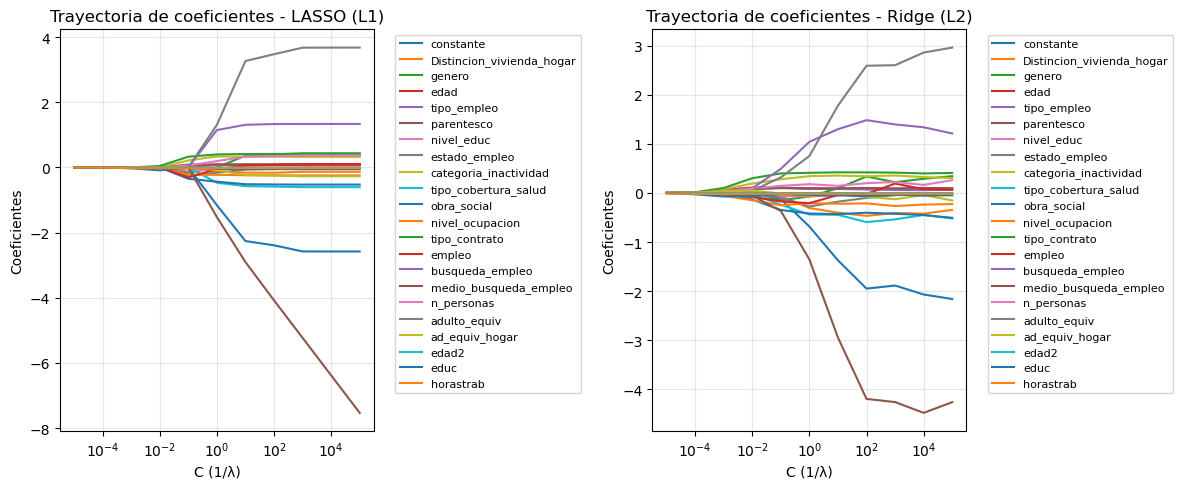

In [11]:
# Definimos grilla de penalización: C = 1/λ
C_grid = np.logspace(-5, 5, 11)  # 11 puntos entre 10^-5 y 10^5

#Guardamos en un array los coeficientes
coefs_lasso = []
coefs_ridge = []

# Entrenamos modelos para cada valor de C y guardamos los coeficientes
for C in C_grid:
    # LASSO
    lasso = LogisticRegression(penalty='l1', solver='liblinear', C=C, random_state=444, max_iter=3000) #Ajustamos
    lasso.fit(Xtr25, ytr25) #entrenamos
    coefs_lasso.append(lasso.coef_.ravel()) # guardamos

    # RIDGE
    ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=C, random_state=444, max_iter=3000)#Ajustamos
    ridge.fit(Xtr25, ytr25)# entrenamos
    coefs_ridge.append(ridge.coef_.ravel()) # guardamos

# Los guardamos en el array que armamos en un principio
coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)


#Plot
plt.figure(figsize=(12,5))

# ---- LASSO ----
plt.subplot(1,2,1)
for i, var in enumerate(Xtr25.columns):
    plt.plot(C_grid, coefs_lasso[:, i], label=var)
plt.xscale('log')
plt.title("Trayectoria de coeficientes - LASSO (L1)")
plt.xlabel("C (1/λ)")
plt.ylabel("Coeficientes")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()

# ---- RIDGE ----
plt.subplot(1,2,2)
for i, var in enumerate(Xtr25.columns):
    plt.plot(C_grid, coefs_ridge[:, i], label=var)
plt.xscale('log')
plt.title("Trayectoria de coeficientes - Ridge (L2)")
plt.xlabel("C (1/λ)")
plt.ylabel("Coeficientes")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()

plt.show()

* 9) Penalidad Optima por Cross-Validation y Visualizacion

λ_opt LASSO (L1): 0.100000
λ_opt RIDGE (L2): 0.100000
C_opt LASSO: 10.000000
C_opt RIDGE: 10.000000


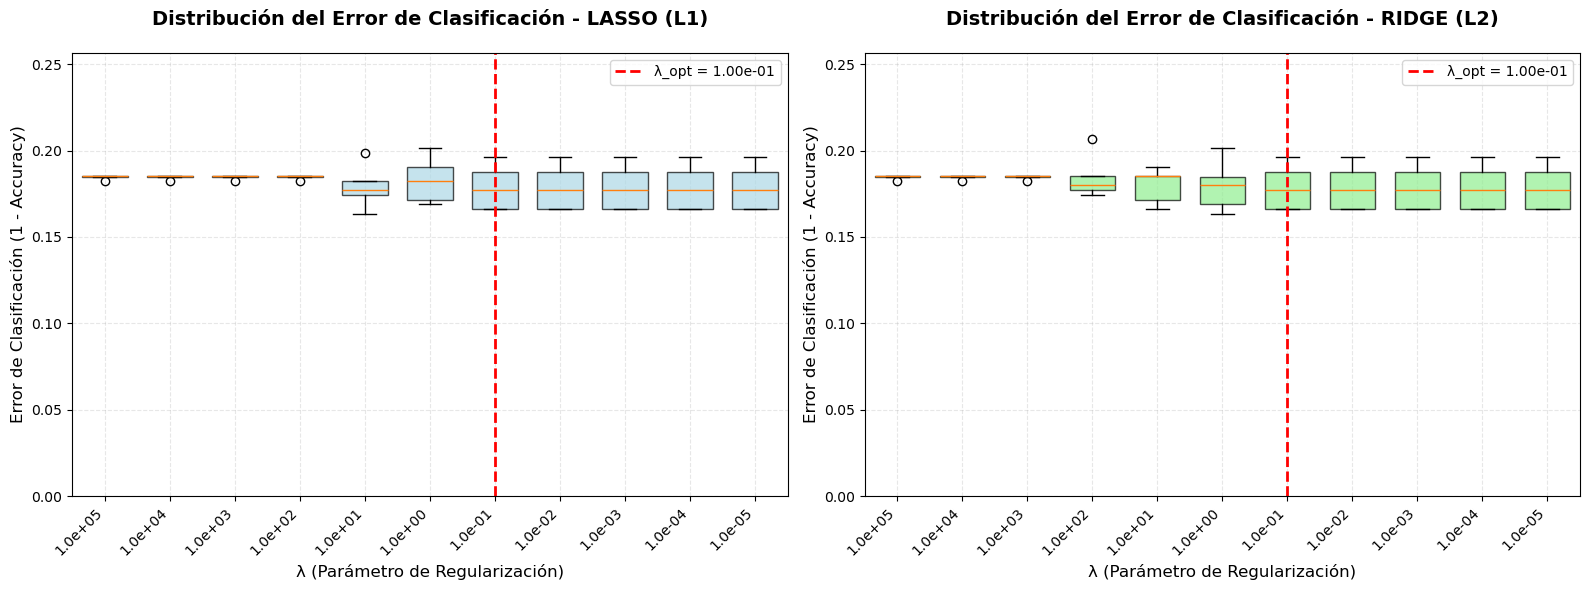

λ = 1.0e+05: Proporción media de vars ignoradas = 1.000
λ = 1.0e+04: Proporción media de vars ignoradas = 1.000
λ = 1.0e+03: Proporción media de vars ignoradas = 1.000
λ = 1.0e+02: Proporción media de vars ignoradas = 0.818
λ = 1.0e+01: Proporción media de vars ignoradas = 0.364
λ = 1.0e+00: Proporción media de vars ignoradas = 0.045
λ = 1.0e-01: Proporción media de vars ignoradas = 0.091
λ = 1.0e-02: Proporción media de vars ignoradas = 0.045
λ = 1.0e-03: Proporción media de vars ignoradas = 0.045
λ = 1.0e-04: Proporción media de vars ignoradas = 0.045
λ = 1.0e-05: Proporción media de vars ignoradas = 0.045


C:\Users\War\AppData\Local\Temp\ipykernel_12768\282635044.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


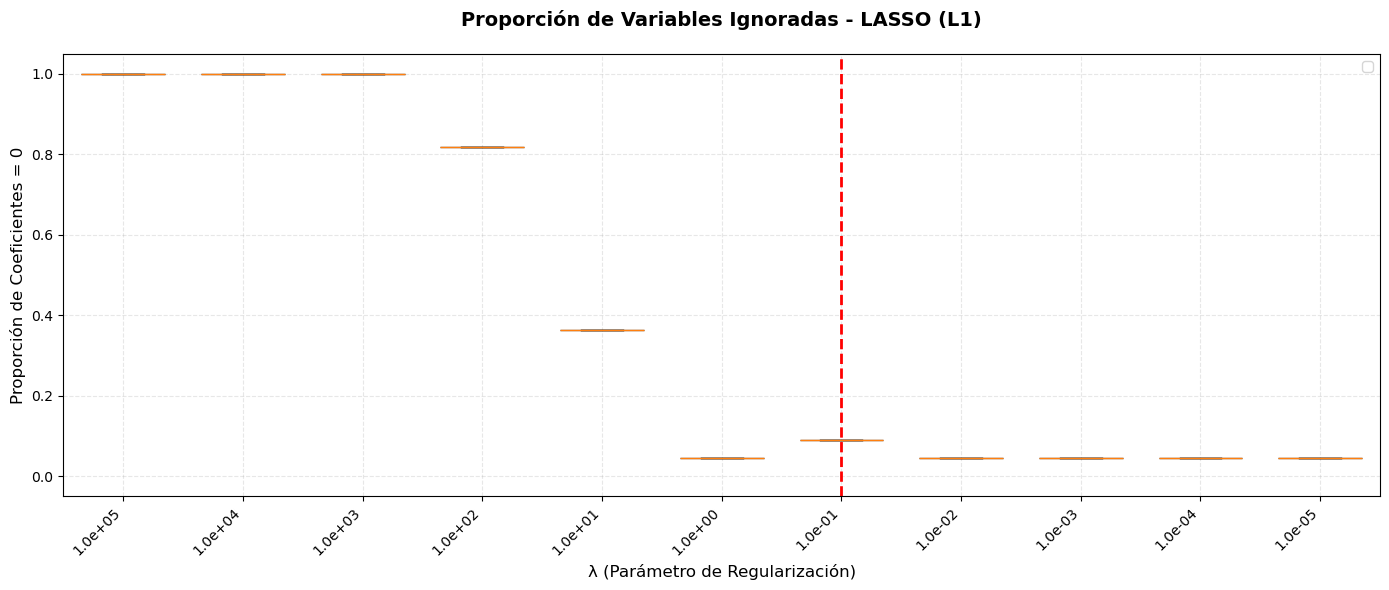

In [12]:
# Configuramos la penalización
C_grid = np.logspace(-5, 5, 11)
lambda_grid = 1 / C_grid

#Estrandarizamos datos
scaler = StandardScaler()
Xtr25_scaled = scaler.fit_transform(Xtr25)

#ENTRENAMIENTO CON LOGISTIC REGRESSION CV (5-FOLD)

# Modelo LASSO (L1)
lasso_cv = LogisticRegressionCV(Cs=C_grid, cv=5, penalty='l1', solver='liblinear', random_state=444, max_iter=5000, scoring='accuracy', n_jobs=-1)
lasso_cv.fit(Xtr25_scaled, ytr25)

# Modelo RIDGE (L2)
ridge_cv = LogisticRegressionCV(Cs=C_grid, cv=5, penalty='l2', solver='lbfgs', random_state=444, max_iter=5000, scoring='accuracy', n_jobs=-1)
ridge_cv.fit(Xtr25_scaled, ytr25)

#RESULTADOS DE λ ÓPTIMO
lambda_opt_lasso = 1 / lasso_cv.C_[0]
lambda_opt_ridge = 1 / ridge_cv.C_[0]

print(f"λ_opt LASSO (L1): {lambda_opt_lasso:.6f}")
print(f"λ_opt RIDGE (L2): {lambda_opt_ridge:.6f}")
print(f"C_opt LASSO: {lasso_cv.C_[0]:.6f}")
print(f"C_opt RIDGE: {ridge_cv.C_[0]:.6f}")

# 4. BOX-PLOTS DEL ERROR DE CLASIFICACIÓN

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Preparar datos para boxplots
error_lasso = 1 - lasso_cv.scores_[1]  # Error = 1 - Accuracy
error_ridge = 1 - ridge_cv.scores_[1]
positions = range(1, len(C_grid) + 1)
labels = [f'{lam:.1e}' for lam in lambda_grid]

#print(error_lasso)
#print(error_ridge)

# BOX-PLOT LASSO
box_lasso = ax1.boxplot([error_lasso[:, i] for i in range(len(C_grid))],
                       positions=positions, widths=0.7, patch_artist=True)
for patch in box_lasso['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax1.set_title('Distribución del Error de Clasificación - LASSO (L1)',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('λ (Parámetro de Regularización)', fontsize=12)
ax1.set_ylabel('Error de Clasificación (1 - Accuracy)', fontsize=12)
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=45, ha='right')
opt_idx_lasso = np.argmin(np.abs(lambda_grid - lambda_opt_lasso))
ax1.axvline(x=positions[opt_idx_lasso], color='red', linestyle='--', linewidth=2,
           label=f'λ_opt = {lambda_opt_lasso:.2e}')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim([0, max(error_lasso.max(), error_ridge.max()) + 0.05])

# BOX-PLOT RIDGE
box_ridge = ax2.boxplot([error_ridge[:, i] for i in range(len(C_grid))],
                       positions=positions, widths=0.7, patch_artist=True)
for patch in box_ridge['boxes']:
    patch.set_facecolor('lightgreen')
    patch.set_alpha(0.7)
ax2.set_title('Distribución del Error de Clasificación - RIDGE (L2)',
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('λ (Parámetro de Regularización)', fontsize=12)
ax2.set_ylabel('Error de Clasificación (1 - Accuracy)', fontsize=12)
ax2.set_xticks(positions)
ax2.set_xticklabels(labels, rotation=45, ha='right')
opt_idx_ridge = np.argmin(np.abs(lambda_grid - lambda_opt_ridge))
ax2.axvline(x=positions[opt_idx_ridge], color='red', linestyle='--', linewidth=2,
           label=f'λ_opt = {lambda_opt_ridge:.2e}')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim([0, max(error_lasso.max(), error_ridge.max()) + 0.05])

plt.tight_layout()
plt.show()

# BOX-PLOT OPCIONAL: PROPORCIÓN DE VARIABLES IGNORADAS (LASSO)
# Para mayor robustez, calcular sobre múltiples random states
random_states = [444, 445, 446, 447, 448]
prop_ceros_por_lambda = []

for i, C in enumerate(C_grid):
    prop_ceros_folds = []
    for rs in random_states:
        model = LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=C,
            random_state=rs,
            max_iter=5000
        )
        model.fit(Xtr25_scaled, ytr25)
        # Calcular proporción de coeficientes iguales a cero
        prop_cero = np.mean(model.coef_.ravel() == 0)
        prop_ceros_folds.append(prop_cero)

    prop_ceros_por_lambda.append(prop_ceros_folds)
    print(f"λ = {lambda_grid[i]:.1e}: Proporción media de vars ignoradas = {np.mean(prop_ceros_folds):.3f}")

# Gráfico de variables ignoradas
plt.figure(figsize=(14, 6))
box_ignoradas = plt.boxplot(prop_ceros_por_lambda, positions=positions, widths=0.7, patch_artist=True)

# Colorear cajas
for patch in box_ignoradas['boxes']:
    patch.set_facecolor('salmon')
    patch.set_alpha(0.7)
plt.title('Proporción de Variables Ignoradas - LASSO (L1)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('λ (Parámetro de Regularización)', fontsize=12)
plt.ylabel('Proporción de Coeficientes = 0', fontsize=12)
plt.xticks(positions, labels, rotation=45, ha='right')
plt.axvline(x=positions[opt_idx_lasso], color='red', linestyle='--', linewidth=2,
           )
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()



* 10) Comparacion de coeficientes

In [13]:
# Recuperamos los valores óptimos de C
C_opt_lasso = lasso_cv.C_[0]
C_opt_ridge = ridge_cv.C_[0]

# Modelo sin penalidad
logit_simple = LogisticRegression(penalty=None, solver='lbfgs', max_iter=3000)
logit_simple.fit(Xtr25, ytr25)

# Modelo LASSO con penalidad óptima
logit_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=C_opt_lasso, max_iter=3000)
logit_lasso.fit(Xtr25, ytr25)

# Modelo Ridge con penalidad óptima
logit_ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=C_opt_ridge, max_iter=3000)
logit_ridge.fit(Xtr25, ytr25)

# Tabla comparativa
coef_df = pd.DataFrame({
    "Variable": Xtr25.columns,
    "Sin penalidad": logit_simple.coef_.ravel(),
    "LASSO (λ^cv)": logit_lasso.coef_.ravel(),
    "Ridge (λ^cv)": logit_ridge.coef_.ravel()
})

# Guardar tabla
coef_df.to_excel("coeficientes_logit_comparacion_2025.xlsx", index=False)

# Mostrar primeras filas
display(coef_df.head(10))


C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = 

,Variable,Sin penalidad,LASSO (λ^cv),Ridge (λ^cv)
0,constante,-2.127174,-2.492832,-1.372620
1,Distincion_vivienda_hogar,-0.432460,-0.133952,-0.400890
2,genero,0.301887,0.387496,0.095094
3,edad,0.086226,0.074392,0.084806
4,tipo_empleo,0.079410,0.095568,0.082338
5,parentesco,0.096471,0.095180,0.093099
6,nivel_educ,-0.018788,-0.010862,-0.047899
7,estado_empleo,-0.032905,-0.035381,-0.177584
8,categoria_inactividad,0.348395,0.326231,0.353935
9,tipo_cobertura_salud,-0.680911,-0.585596,-0.445631


# Bonus : Elastic Net

In [14]:
# Definir rango de C (inverso de lambda) y ratios L1
C_grid = np.logspace(-3, 2, 20)  # Ejemplo: de 0.001 a 100
l1_ratios = np.linspace(0.1, 0.9, 5)  # De 10% a 90% L1

# Entrenamiento
elastic_cv = LogisticRegressionCV(Cs=C_grid,cv=5,penalty='elasticnet',solver='saga',l1_ratios=l1_ratios,random_state=444,max_iter=3000,scoring='accuracy')
elastic_cv.fit(Xtr25, ytr25)

print(f"C óptimo Elastic Net: {elastic_cv.C_[0]:.4f}")
print(f"Ratio L1 óptimo: {elastic_cv.l1_ratio_[0]:.2f}")

# Tabla
coef_elastic = pd.DataFrame({
    "Variable": Xtr25.columns,
    "Coef_ElasticNet": elastic_cv.coef_.ravel()
})
display(coef_elastic.head(10))

C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached 

C óptimo Elastic Net: 0.0010
Ratio L1 óptimo: 0.10


,Variable,Coef_ElasticNet
0,constante,0.000000
1,Distincion_vivienda_hogar,0.000000
2,genero,0.000000
3,edad,-0.010629
4,tipo_empleo,-0.006129
5,parentesco,0.000000
6,nivel_educ,-0.007550
7,estado_empleo,0.000000
8,categoria_inactividad,0.000000
9,tipo_cobertura_salud,0.000000


C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\War\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


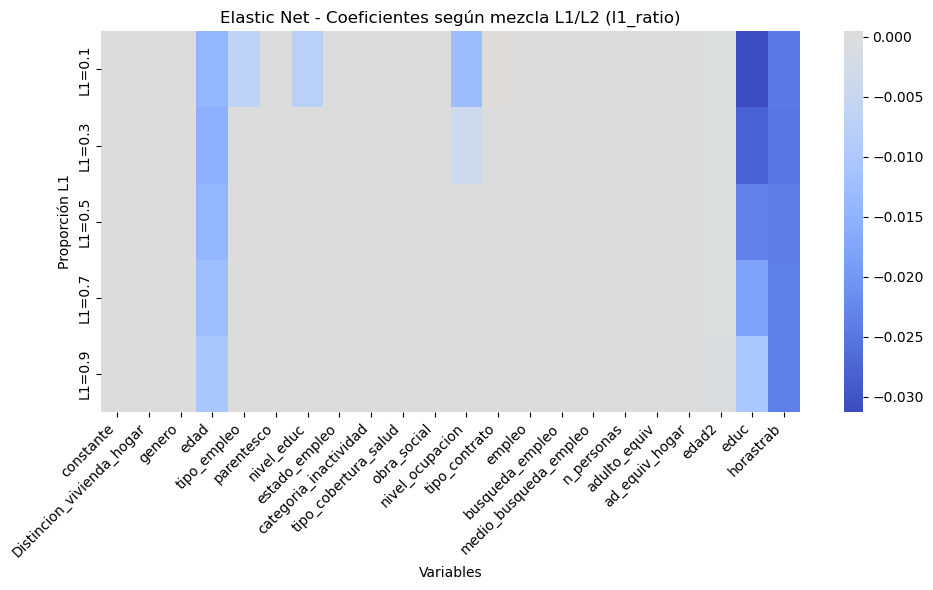

In [15]:
l1_ratios = np.linspace(0.1, 0.9, 5)
coefs_elastic = []

for ratio in l1_ratios:
    model = LogisticRegression(
        penalty='elasticnet', solver='saga',
        l1_ratio=ratio, C=elastic_cv.C_[0],
        random_state=444, max_iter=3000
    )
    model.fit(Xtr25, ytr25)
    coefs_elastic.append(model.coef_.ravel())

coefs_elastic = pd.DataFrame(coefs_elastic, columns=Xtr25.columns, index=[f"L1={r:.1f}" for r in l1_ratios])

plt.figure(figsize=(10,6))
sns.heatmap(coefs_elastic, cmap="coolwarm", center=0, annot=False)
plt.title("Elastic Net - Coeficientes según mezcla L1/L2 (l1_ratio)")
plt.xlabel("Variables")
plt.ylabel("Proporción L1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [16]:
# en este paso importo librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, accuracy_score, f1_score
)

# en este paso defino listas de columnas y elimino identificadores o alta cardinalidad
cols_obj = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
cols_num = X_train.select_dtypes(include=[np.number]).columns.tolist()

# en este paso marco columnas de alta cardinalidad y posibles IDs para excluir
alta_card = [c for c in cols_obj if X_train[c].nunique(dropna=True) > 50]
parecen_id = [c for c in X_train.columns
              if c.lower() in {"codusu","id","dni","documento"} or "id" in c.lower()]

a_excluir = sorted(set(alta_card + parecen_id))
if a_excluir:
    print("Columnas excluidas por no predictivas:", a_excluir)

# en este paso construyo X filtradas
X_train_f = X_train.drop(columns=[c for c in a_excluir if c in X_train.columns], errors="ignore")
X_test_f  = X_test.drop(columns=[c for c in a_excluir if c in X_test.columns], errors="ignore")

# en este paso detecto tipos luego del filtrado
num_cols = X_train_f.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_f.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"numéricas: {len(num_cols)}, categóricas: {len(cat_cols)}")

# en este paso armo el preprocesamiento por tipo
num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])
cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore", sparse=False))
])

prep = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
], remainder="drop")

# en este paso defino la CV
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=444)

# en este paso armo los cuatro modelos

# 1) Logit clásico
logit = Pipeline([
    ("prep", prep),
    ("clf", LogisticRegression(max_iter=5000, solver="lbfgs"))
])

# 2) KNN con búsqueda de K
knn_base = Pipeline([
    ("prep", prep),
    ("clf", KNeighborsClassifier())
])
param_knn = {
    "clf__n_neighbors": list(range(3, 36, 2)),
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2]
}
knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_knn,
    scoring="roc_auc",
    cv=cv5,
    n_jobs=-1,
    refit=True
)

# 3) Logit LASSO con λ^cv  (C = 1/λ)
lasso = Pipeline([
    ("prep", prep),
    ("clf", LogisticRegressionCV(
        Cs=25,
        cv=cv5,
        penalty="l1",
        solver="saga",
        scoring="roc_auc",
        max_iter=10000,
        n_jobs=-1,
        refit=True
    ))
])

# 4) Logit Ridge con λ^cv
ridge = Pipeline([
    ("prep", prep),
    ("clf", LogisticRegressionCV(
        Cs=25,
        cv=cv5,
        penalty="l2",
        solver="lbfgs",
        scoring="roc_auc",
        max_iter=10000,
        n_jobs=-1,
        refit=True
    ))
])

# en este paso ajusto
logit.fit(X_train_f, y_train)
knn.fit(X_train_f, y_train)
lasso.fit(X_train_f, y_train)
ridge.fit(X_train_f, y_train)

# en este paso obtengo probabilidades en test
proba_logit = logit.predict_proba(X_test_f)[:, 1]
proba_knn   = knn.predict_proba(X_test_f)[:, 1]
proba_lasso = lasso.predict_proba(X_test_f)[:, 1]
proba_ridge = ridge.predict_proba(X_test_f)[:, 1]

# en este paso matriz de confusión para logit con umbral 0.5
yhat_logit_05 = (proba_logit > 0.5).astype(int)
cm = confusion_matrix(y_test, yhat_logit_05, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(ax=ax, colorbar=False)
plt.title("Matriz de confusión Logit (umbral 0.5)")
plt.tight_layout()
plt.show()

# en este paso curvas ROC y AUC
from sklearn.metrics import RocCurveDisplay

fpr_logit, tpr_logit, _ = roc_curve(y_test, proba_logit, pos_label=1)
fpr_knn,   tpr_knn,   _ = roc_curve(y_test, proba_knn,   pos_label=1)
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, proba_lasso, pos_label=1)
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, proba_ridge, pos_label=1)

auc_logit = auc(fpr_logit, tpr_logit)
auc_knn   = auc(fpr_knn,   tpr_knn)
auc_lasso = auc(fpr_lasso, tpr_lasso)
auc_ridge = auc(fpr_ridge, tpr_ridge)

plt.figure(figsize=(6,6))
plt.plot(fpr_logit, tpr_logit, label=f"Logit AUC={auc_logit:.3f}")
plt.plot(fpr_knn,   tpr_knn,   label=f"KNN AUC={auc_knn:.3f}")
plt.plot(fpr_lasso, tpr_lasso, label=f"LASSO AUC={auc_lasso:.3f}")
plt.plot(fpr_ridge, tpr_ridge, label=f"Ridge AUC={auc_ridge:.3f}")
plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.title("Curvas ROC en X_test 2025")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# en este paso calculo métricas con umbral 0.5
def bin_metrics(y_true, proba, thr=0.5):
    yhat = (proba > thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, yhat),
        "f1": f1_score(y_true, yhat, zero_division=0)
    }

m_logit = bin_metrics(y_test, proba_logit, thr=0.5)
m_knn   = bin_metrics(y_test, proba_knn,   thr=0.5)
m_lasso = bin_metrics(y_test, proba_lasso, thr=0.5)
m_ridge = bin_metrics(y_test, proba_ridge, thr=0.5)

tabla = pd.DataFrame.from_dict(
    {
        "Logit": m_logit,
        "KNN (K^cv)": m_knn,
        "Logit LASSO (λ^cv)": m_lasso,
        "Logit Ridge (λ^cv)": m_ridge
    },
    orient="index"
).round(3)

# en este paso muestro hiperparámetros elegidos
try:
    print("KNN seleccionado por CV:", knn.best_params_)
except Exception:
    pass

try:
    C_lasso = lasso.named_steps["clf"].C_[0]
    print(f"LASSO C^cv={C_lasso:.4f}  (λ^cv≈{1/C_lasso:.4f})")
except Exception:
    pass

try:
    C_ridge = ridge.named_steps["clf"].C_[0]
    print(f"Ridge C^cv={C_ridge:.4f}  (λ^cv≈{1/C_ridge:.4f})")
except Exception:
    pass

print("\nTabla de métricas con umbral 0.5")
display(tabla)



NameError: name 'X_train' is not defined